# Regression Watch: skill or luck?

This notebook asks one question about fantasy football players: **when a player scores more
than his chances were worth, will it last?** It is written for someone in their first fantasy
season. Every number below is computed from the project's own warehouse when the notebook
runs; nothing is typed in by hand.

What you need before running it (local, nothing is downloaded):

```bash
uv run twm build        # the warehouse (data/warehouse.duckdb)
```

The same numbers, with more detail, are in `reports/regression_watch/stability.md`
(`uv run twm regression stability`); `docs/regression_watch.md` explains every column.

In [1]:
import io
import os

import polars as pl
from IPython.display import Image, display
from matplotlib.figure import Figure

from twm.asof import AsOfView
from twm.config import FANTASY_POSITIONS, ROOT, settings
from twm.modules.regression_watch import player_week as pw
from twm.modules.regression_watch import stability as st

os.chdir(ROOT)  # every path below is relative to the project folder
pl.Config.set_tbl_hide_dataframe_shape(True)
pl.Config.set_float_precision(2)
pl.Config.set_tbl_rows(20)
SEASONS = list(range(st.FIRST_STUDY_SEASON, settings().current_season))  # complete seasons
frame = st.load_frame(None, SEASONS)  # one row per player-game, read through the as-of view
with AsOfView(settings().path("warehouse"), pw.END_OF_TIME) as view:
    names = view.sql("SELECT gsis_id, display_name FROM dim_player")
print(f"seasons {SEASONS[0]}-{SEASONS[-1]}: {frame.height:,} player-games")

seasons 2009-2025: 94,267 player-games


## 1. Opportunity and efficiency

A player's fantasy points come from two things:

- **Opportunity**: how many chances he gets and how good they are. A target 5 yards from the
  end zone is worth more than a screen pass at midfield. **xFP (expected fantasy points)** is
  what an *average* player would have scored from exactly his targets, carries and passes.
- **Efficiency**: what he did with them. **FPOE (fantasy points over expected)** = points -
  xFP. +5 means he scored 5 points more than an average player would have.

Here is the wide receiver with the highest FPOE per game in the last complete season (at least
8 games):

In [2]:
last = SEASONS[-1]
games = st.study_games(frame, [last])
wr = (
    games.filter(pl.col("position") == "WR")
    .group_by("gsis_id")
    .agg(pl.len().alias("games"), pl.col("fpoe").mean().alias("FPOE/game"))
    .sort("FPOE/game", descending=True)
    .join(names, on="gsis_id", how="left")
)
star = wr.row(0, named=True)
print(
    f"{star['display_name']}, {last}: {star['games']} games, FPOE {star['FPOE/game']:+.1f} per game"
)
games.filter(pl.col("gsis_id") == star["gsis_id"]).select(
    "week", pl.col("fantasy_points").alias("points"), "xfp", "fpoe"
)

Puka Nacua, 2025: 16 games, FPOE +4.4 per game


week,points,xfp,fpoe
i32,f64,f64,f64
1,23.10,19.00,4.09
2,27.60,16.46,11.14
3,22.80,23.25,-0.45
4,36.00,25.44,10.56
5,24.50,21.12,3.38
6,4.80,6.33,-1.53
9,22.80,18.71,4.09
10,17.40,8.83,8.57
11,14.30,13.95,0.35


His points swing a lot from week to week, and so does his FPOE. Is his FPOE a skill he
will keep, or did he get lucky (a long touchdown, a broken tackle)? One season is too short to
tell for one player, but we can ask the question of **thousands** of player-seasons at once.

## 2. Splitting a season in two

The trick: take every player-season with at least 8 games (a game counts when he had a
target, carry or pass) and split his games into two halves: his **odd** games (1st, 3rd, 5th
...) and his **even** games (2nd, 4th, 6th ...). Both halves come from the same player in the
same season, with the same coach and teammates. Only the luck differs.

If FPOE were pure skill, a player's FPOE in his odd games would predict his FPOE in his even
games. If it were pure luck, it would predict nothing. The **correlation** (r) between the two
halves measures this: 1 = the halves agree perfectly, 0 = no relation at all.

How many player-seasons are in the study, by position:

In [3]:
study = st.study_games(frame, SEASONS)
(
    study.group_by("position", "season", "gsis_id")
    .agg(pl.len().alias("games"))
    .group_by("position")
    .agg(pl.len().alias("player-seasons"), pl.col("games").median().alias("median games"))
    .sort(pl.col("position").replace_strict({p: i for i, p in enumerate(FANTASY_POSITIONS)}))
)

position,player-seasons,median games
str,u32,f64
"""QB""",607,15.00
"""RB""",1476,14.00
"""WR""",2240,14.00
"""TE""",1098,13.00


## 3. Opportunity is sticky, efficiency is not

The split-half correlation of xFP per game (opportunity), FPOE per game (efficiency) and
fantasy points per game, by position. In brackets: a 95% interval (the range the true value
probably lies in, from re-drawing the player-seasons 1,000 times).

In [4]:
sh = st.split_half(frame, SEASONS)
odd_even = sh.filter(pl.col("split") == "odd_even")


def cell(pos, metric, split="odd_even"):
    r = sh.filter(
        (pl.col("split") == split) & (pl.col("position") == pos) & (pl.col("metric") == metric)
    ).row(0, named=True)
    return f"{r['r']:.2f} ({r['lo']:.2f} to {r['hi']:.2f})"


pl.DataFrame(
    [
        {
            "position": p,
            "xFP/game": cell(p, "xfp"),
            "FPOE/game": cell(p, "fpoe"),
            "points/game": cell(p, "fantasy_points"),
        }
        for p in FANTASY_POSITIONS
    ]
)

position,xFP/game,FPOE/game,points/game
str,str,str,str
"""QB""","""0.76 (0.72 to 0.80)""","""0.10 (0.01 to 0.18)""","""0.70 (0.66 to 0.74)"""
"""RB""","""0.88 (0.87 to 0.89)""","""0.16 (0.10 to 0.22)""","""0.82 (0.81 to 0.84)"""
"""WR""","""0.85 (0.84 to 0.86)""","""0.11 (0.06 to 0.15)""","""0.77 (0.75 to 0.79)"""
"""TE""","""0.85 (0.83 to 0.87)""","""0.12 (0.05 to 0.18)""","""0.75 (0.72 to 0.78)"""


In [5]:
xfp_r = odd_even.filter(pl.col("metric") == "xfp")["r"]
fpoe_r = odd_even.filter(pl.col("metric") == "fpoe")["r"]
print(
    f"xFP/game repeats with r {xfp_r.min():.2f} to {xfp_r.max():.2f}; "
    f"FPOE/game with r {fpoe_r.min():.2f} to {fpoe_r.max():.2f}"
)
print("opportunity stickier than efficiency at every position:", xfp_r.min() > fpoe_r.max())

xFP/game repeats with r 0.76 to 0.88; FPOE/game with r 0.10 to 0.16
opportunity stickier than efficiency at every position: True


A picture of the same thing for wide receivers: each dot is one player-season, his odd
games across, his even games up. On the left (opportunity) the dots line up: a receiver who
gets many good targets in his odd games gets them in his even games too. On the right
(efficiency) they form a shapeless cloud: beating expectations in one half says little about
the other.

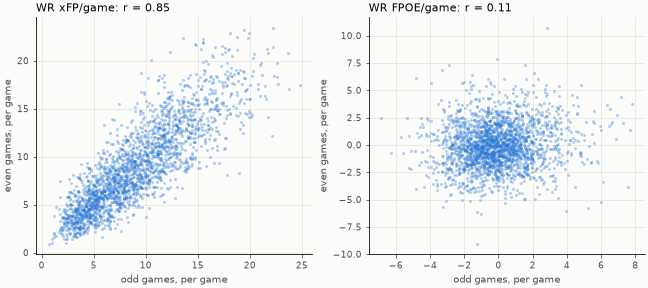

In [6]:
BLUE, INK, GRID, SURFACE = "#2a78d6", "#52514e", "#e1e0d9", "#fcfcfb"


def show(fig):
    buf = io.BytesIO()
    fig.savefig(buf, format="png", dpi=72, facecolor=SURFACE)
    display(Image(buf.getvalue()))


def style(ax):
    ax.set_facecolor(SURFACE)
    ax.grid(color=GRID, linewidth=0.6)
    ax.set_axisbelow(True)
    for side in ("top", "right"):
        ax.spines[side].set_visible(False)
    ax.tick_params(colors=INK, labelsize=9)


halves = st.halves(study, "odd_even")
fig = Figure(figsize=(9, 4), layout="constrained", facecolor=SURFACE)
for ax, name in zip(fig.subplots(1, 2), ("xfp", "fpoe"), strict=True):
    m = st.METRIC_BY_NAME[name]
    p = st.pairs(halves, m, "WR")
    ax.scatter(p.a, p.b, s=9, alpha=0.35, color=BLUE, linewidths=0)
    ax.set_title(f"WR {m.label}: r = {st.pearson(p.a, p.b):.2f}", loc="left", fontsize=11)
    ax.set_xlabel("odd games, per game", color=INK)
    ax.set_ylabel("even games, per game", color=INK)
    style(ax)
show(fig)

## 4. The parts of efficiency

FPOE mixes several things. Each can be measured as a rate over expected, per chance:

- **TD rate over expected**: touchdowns minus expected touchdowns, per pass, carry or target;
- **catch rate over expected**: catches minus expected catches, per target (for QBs the same
  for completions, often called CPOE);
- **YAC over expected**: yards after the catch minus what an average receiver gains after the
  same catches, per catch.

A rate counts only for player-seasons with at least 10 chances in each half. Which parts
repeat at all?

In [7]:
rows = []
for p in FANTASY_POSITIONS:
    rate = "completion_rate_over_expected" if p == "QB" else "catch_rate_over_expected"
    rows.append(
        {
            "position": p,
            "TD rate": cell(p, "td_rate_over_expected"),
            "catch rate (QB: completions)": cell(p, rate),
            "YAC per catch": cell(p, "yac_over_expected") if p != "QB" else "-",
        }
    )
pl.DataFrame(rows)

position,TD rate,catch rate (QB: completions),YAC per catch
str,str,str,str
"""QB""","""0.00 (-0.13 to 0.15)""","""0.33 (0.26 to 0.40)""","""-"""
"""RB""","""0.06 (-0.01 to 0.14)""","""0.09 (0.02 to 0.15)""","""0.03 (-0.06 to 0.11)"""
"""WR""","""0.03 (-0.02 to 0.08)""","""0.16 (0.11 to 0.21)""","""0.19 (0.14 to 0.24)"""
"""TE""","""0.00 (-0.07 to 0.08)""","""0.16 (0.10 to 0.23)""","""0.21 (0.13 to 0.29)"""


Touchdowns over expected barely repeat at any position: scoring more touchdowns than your
chances were worth is mostly luck. Catching more passes than expected, completing more passes
than expected (QBs) and gaining extra yards after the catch (WRs and TEs) repeat a little more:
those are closer to real skills, though still noisy over half a season.

## 5. Without garbage time

**Garbage time** is when the game is already decided (one team's win probability is below 5%
or above 95%, outside a close game's final two minutes). Points then come against soft
defenses. Do the numbers get more stable without them?

In [8]:
pl.DataFrame(
    [
        {
            "position": p,
            "xFP/game": cell(p, "xfp"),
            "xFP/game, no garbage": cell(p, "xfp_ng"),
            "FPOE/game": cell(p, "fpoe"),
            "FPOE/game, no garbage": cell(p, "fpoe_ng"),
        }
        for p in FANTASY_POSITIONS
    ]
)

position,xFP/game,"xFP/game, no garbage",FPOE/game,"FPOE/game, no garbage"
str,str,str,str,str
"""QB""","""0.76 (0.72 to 0.80)""","""0.71 (0.66 to 0.75)""","""0.10 (0.01 to 0.18)""","""0.09 (0.01 to 0.17)"""
"""RB""","""0.88 (0.87 to 0.89)""","""0.87 (0.86 to 0.88)""","""0.16 (0.10 to 0.22)""","""0.13 (0.06 to 0.19)"""
"""WR""","""0.85 (0.84 to 0.86)""","""0.82 (0.81 to 0.83)""","""0.11 (0.06 to 0.15)""","""0.08 (0.03 to 0.12)"""
"""TE""","""0.85 (0.83 to 0.87)""","""0.82 (0.80 to 0.84)""","""0.12 (0.05 to 0.18)""","""0.11 (0.04 to 0.17)"""


Dropping garbage time does not make efficiency more repeatable here: it also removes about
a sixth of every player's chances, and fewer chances mean more luck in what is left. The
garbage-time toggle is still useful to *see* how a player's points were made.

## 6. How much FPOE to believe: the shrinkage factor

Think of every game's FPOE as **true level + luck**. After a few games the average is mostly
luck; after many games more of it is real. Two numbers per position describe this:

- the **signal variance**: how much players' true levels differ (estimated from how much the
  odd and even halves move together);
- the **noise variance per game**: how much a single game swings by luck (from how much the
  two halves differ).

After g games, the share of his FPOE/game that is real is the **reliability**

  r(g) = signal / (signal + noise / g).

That share is the **shrinkage factor**: the rest-of-season projection (step D3) keeps r(g) of a
player's FPOE/game and lets the rest fade. It is also called *empirical Bayes* shrinkage.

In [9]:
table = st.shrinkage(SEASONS, frame=frame)
fp = table.filter(pl.col("metric") == "fpoe")
(
    fp.filter(pl.col("g").is_in([4, 8, 12, 17]))
    .pivot(on="g", index="position", values="reliability")
    .rename({g: f"r({g})" for g in ("4", "8", "12", "17")})
    .join(
        fp.filter(pl.col("g") == 1).select("position", "var_signal", "var_noise", "n"),
        on="position",
    )
)

position,r(4),r(8),r(12),r(17),var_signal,var_noise,n
str,f64,f64,f64,f64,f64,f64,i64
"""QB""",0.06,0.12,0.17,0.22,0.59,34.90,607
"""RB""",0.11,0.20,0.27,0.35,0.54,17.25,1476
"""WR""",0.07,0.13,0.19,0.25,0.43,22.12,2240
"""TE""",0.08,0.15,0.21,0.27,0.27,12.45,1098


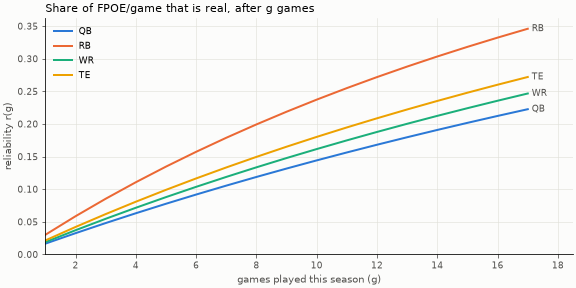

In [10]:
COLORS = {"QB": "#2a78d6", "RB": "#eb6834", "WR": "#1baf7a", "TE": "#eda100"}
fig = Figure(figsize=(8, 4), layout="constrained", facecolor=SURFACE)
ax = fig.subplots()
for pos in FANTASY_POSITIONS:
    one = fp.filter(pl.col("position") == pos).sort("g")
    ax.plot(one["g"], one["reliability"], color=COLORS[pos], linewidth=2, label=pos)
    ax.annotate(
        pos,
        (one["g"][-1], one["reliability"][-1]),
        xytext=(4, 0),
        textcoords="offset points",
        va="center",
        fontsize=9,
        color=INK,
    )
ax.set_title("Share of FPOE/game that is real, after g games", loc="left", fontsize=11)
ax.set_xlabel("games played this season (g)", color=INK)
ax.set_ylabel("reliability r(g)", color=INK)
ax.set_xlim(1, st.MAX_G + 1.5)
ax.set_ylim(0, None)
ax.legend(frameon=False, fontsize=9, loc="upper left")
style(ax)
show(fig)

Back to the receiver from section 1. After his games, how much of his FPOE per game should a
projection keep?

In [11]:
g = star["games"]
r = st.shrinkage_factor(table, "WR", g)
print(f"{star['display_name']}: FPOE {star['FPOE/game']:+.1f} per game over {g} games")
print(
    f"r({g}) = {r:.2f}: keep {r * star['FPOE/game']:+.1f} points per game of it, "
    f"expect the other {(1 - r) * star['FPOE/game']:+.1f} to fade"
)

Puka Nacua: FPOE +4.4 per game over 16 games
r(16) = 0.24: keep +1.0 points per game of it, expect the other +3.4 to fade


## 7. Point in time: what a backtest may use

To test the projections honestly (step D3), a projection for season S may only use what was
known before S. `st.shrinkage(seasons)` estimates the table from the seasons it is given and
nothing else, so a backtest for 2016 passes 2009-2015. How different is that table from the
one estimated on every season, and does adding later seasons ever change it?

In [12]:
early = st.shrinkage(range(2009, 2016), frame=frame)
compare = (
    early.filter((pl.col("metric") == "fpoe") & (pl.col("g") == 8))
    .select("position", pl.col("reliability").alias("r(8), 2009-2015"))
    .join(
        fp.filter(pl.col("g") == 8).select(
            "position", pl.col("reliability").alias(f"r(8), {SEASONS[0]}-{SEASONS[-1]}")
        ),
        on="position",
    )
)
same = early.equals(st.shrinkage(range(2009, 2016), frame=frame.filter(pl.col("season") < 2016)))
print("2009-2015 table unchanged when later seasons are removed from the data:", same)
compare

2009-2015 table unchanged when later seasons are removed from the data: True


position,"r(8), 2009-2015","r(8), 2009-2025"
str,f64,f64
"""QB""",0.17,0.12
"""RB""",0.31,0.20
"""WR""",0.17,0.13
"""TE""",0.16,0.15


The estimates move from one set of seasons to another (a few hundred player-seasons per
position is not a lot), which is why the report also shows them on several windows. What
does not move is the big picture: after half a season, most of a player's FPOE is still luck.

## 8. What this means for your team

- **Trust opportunity over results.** Targets, carries and red-zone looks repeat; points
  beyond what those chances were worth mostly do not.
- **A player far above his xFP is a sell-high candidate**, a player far below it a buy-low
  candidate, unless his role is changing.
- **Touchdowns are the least repeatable part** of efficiency; catch rate and yards after the
  catch carry a little more skill.
- Step D3 turns this into rest-of-season projections (xFP per game + the shrunk FPOE) and tests
  them on past seasons before any Sell-high or Buy-low tag is shown.